# EDA HoopR

- Main: https://hoopr.sportsdataverse.org/index.html#hoopr-
- Play-by-play: https://hoopr.sportsdataverse.org/reference/load_mbb_pbp.html

Hoop R is Play-by-Play (PBP) data for Men's College Basketball. It captures every discrete event a player was involved in. 

Every row in this dataset represents a single event on the court. It shows the action, text description and the time.

It is typically updated daily during the active college basketball season.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import seaborn as sns



# Set style for nicer looking plots
sns.set_theme(style="whitegrid")

In [ ]:
#!pip install pyarrow

In [ ]:
# BASE_URL = "https://github.com/sportsdataverse/sportsdataverse-data/releases/download/espn_mens_college_basketball_pbp/play_by_play_{season}.parquet"

# dfs = []
# for season in range(2022, 2027):
#     url = BASE_URL.format(season=season)
#     for attempt in range(3):
#         try:
#             dfs.append(pd.read_parquet(url))
#             print(f"Loaded {season}")
#             time.sleep(3)
#             break
#         except Exception as e:
#             if attempt < 2:
#                 print(f"  {season} attempt {attempt+1} failed, retrying in 15s...")
#                 time.sleep(15)
#             else:
#                 print(f"Skipped {season}: {e}")

# df = pd.concat(dfs, ignore_index=True)
# print(f"\nTotal rows: {len(df):,}")


In [3]:
BASE_URL       = "https://github.com/sportsdataverse/sportsdataverse-data/releases/download/espn_mens_college_basketball_pbp/play_by_play_{season}.parquet"
DATA_PATH_2026 = "../data/mbb_pbp_2026.parquet"

if os.path.exists(DATA_PATH_2026):
    df = pd.read_parquet(DATA_PATH_2026)
    print(f"Loaded local cache: {len(df):,} rows")
else:
    os.makedirs("../data", exist_ok=True)
    url = BASE_URL.format(season=2026)
    print("Downloading 2026 parquet from URL...")
    df = pd.read_parquet(url)
    df.to_parquet(DATA_PATH_2026, index=False)
    print(f"Saved local cache: {len(df):,} rows")

print(df.shape)

Saved local cache: 2,915,731 rows
(2915731, 57)


In [4]:
df.head()

,game_play_number,id,sequence_number,type_id,type_text,text,away_score,home_score,period_number,period_display_value,...,end_game_seconds_remaining,team_id,athlete_id_1,lag_period,lag_half,athlete_id_2,coordinate_x,coordinate_y,game_date,game_date_time
0,1,4.018566e+17,120416832,615,Jumpball,Start game,0,0,1,1st Half,...,2400.0,NaN,NaN,NaN,NaN,NaN,-41.75,0.0,2026-04-06,2026-04-06 20:50:00-04:00
1,2,4.018566e+17,120416833,615,Jumpball,Jump Ball won by UConn,0,0,1,1st Half,...,2396.0,41.0,5105809.0,1.0,1.0,NaN,-41.75,0.0,2026-04-06,2026-04-06 20:50:00-04:00
2,3,4.018566e+17,120416834,615,Jumpball,Jump Ball lost by Michigan,0,0,1,1st Half,...,2374.0,130.0,5174983.0,1.0,1.0,NaN,41.75,-0.0,2026-04-06,2026-04-06 20:50:00-04:00
3,4,4.018566e+17,120416835,558,JumpShot,Tarris Reed Jr. misses 10-foot hook shot,0,0,1,1st Half,...,2370.0,41.0,5105809.0,1.0,1.0,NaN,-31.75,2.0,2026-04-06,2026-04-06 20:50:00-04:00
4,5,4.018566e+17,120416836,587,Defensive Rebound,Elliot Cadeau Defensive Rebound.,0,0,1,1st Half,...,2358.0,130.0,4869764.0,1.0,1.0,NaN,41.75,-0.0,2026-04-06,2026-04-06 20:50:00-04:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2915731 entries, 0 to 2915730
Data columns (total 57 columns):
 #   Column                          Dtype                           
---  ------                          -----                           
 0   game_play_number                int32                           
 1   id                              float64                         
 2   sequence_number                 int32                           
 3   type_id                         int32                           
 4   type_text                       object                          
 5   text                            object                          
 6   away_score                      int32                           
 7   home_score                      int32                           
 8   period_number                   int32                           
 9   period_display_value            object                          
 10  clock_display_value             object    

In [6]:
# Get statistical summaries of numerical columns
df.describe()

,game_play_number,id,sequence_number,type_id,away_score,home_score,period_number,score_value,coordinate_x_raw,coordinate_y_raw,...,start_game_seconds_remaining,end_period_seconds_remaining,end_game_seconds_remaining,team_id,athlete_id_1,lag_period,lag_half,athlete_id_2,coordinate_x,coordinate_y
count,2.915731e+06,2.915731e+06,2.915731e+06,2.915731e+06,2.915731e+06,2.915731e+06,2.915731e+06,2.915731e+06,2.915731e+06,2.915731e+06,...,2.915731e+06,2.909457e+06,2.909457e+06,2.838163e+06,2.713304e+06,2.909456e+06,2.909456e+06,1.706860e+05,2.915731e+06,2.915731e+06
mean,2.358743e+02,4.018222e+17,1.169717e+08,5.683556e+02,3.532892e+01,4.005819e+01,1.531245e+00,6.936514e-01,-1.058054e+06,-1.058071e+06,...,1.140170e+03,5.645978e+02,1.137460e+03,2.884488e+03,5.123924e+06,1.530101e+00,1.530101e+00,5.117918e+06,-1.856053e+04,-1.856021e+04
std,1.394883e+02,1.122904e+13,1.995301e+06,3.295227e+01,2.215668e+01,2.474059e+01,5.213782e-01,1.058323e+00,1.503667e+07,1.503667e+07,...,6.964775e+02,3.485523e+02,6.947707e+02,1.317571e+04,2.053554e+05,5.211921e-01,5.211921e-01,1.926013e+05,1.507384e+07,1.507384e+07
min,1.000000e+00,4.018048e+17,1.135234e+08,9.100000e+01,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-2.147483e+08,-2.147484e+08,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.790000e+02,1.000000e+00,1.000000e+00,1.855300e+04,-2.147484e+08,-2.147484e+08
25%,1.170000e+02,4.018133e+17,1.152228e+08,5.580000e+02,1.700000e+01,1.900000e+01,1.000000e+00,0.000000e+00,2.500000e+01,0.000000e+00,...,5.320000e+02,2.600000e+02,5.310000e+02,1.970000e+02,5.105642e+06,1.000000e+00,1.000000e+00,5.105562e+06,-4.175000e+01,0.000000e+00
50%,2.330000e+02,4.018232e+17,1.169584e+08,5.840000e+02,3.400000e+01,3.800000e+01,2.000000e+00,0.000000e+00,2.500000e+01,0.000000e+00,...,1.168000e+03,5.610000e+02,1.164000e+03,2.084000e+03,5.176218e+06,2.000000e+00,2.000000e+00,5.175850e+06,-1.275000e+01,0.000000e+00
75%,3.490000e+02,4.018276e+17,1.187050e+08,5.860000e+02,5.200000e+01,5.900000e+01,2.000000e+00,2.000000e+00,2.500000e+01,4.000000e+00,...,1.741000e+03,8.560000e+02,1.737000e+03,2.492000e+03,5.242946e+06,2.000000e+00,2.000000e+00,5.242268e+06,4.175000e+01,0.000000e+00
max,8.330000e+02,4.018613e+17,1.204175e+08,6.180000e+02,1.190000e+02,1.490000e+02,5.000000e+00,3.000000e+00,5.000000e+01,8.900000e+01,...,2.406000e+03,1.200000e+03,2.400000e+03,1.320130e+05,5.335077e+06,5.000000e+00,5.000000e+00,5.332823e+06,2.147484e+08,2.147484e+08


In [7]:
df.isnull().sum()

game_play_number                        0
id                                      0
sequence_number                         0
type_id                                 0
type_text                               0
text                                  188
away_score                              0
home_score                              0
period_number                           0
period_display_value                    0
clock_display_value                     0
scoring_play                            0
score_value                             0
wallclock                               0
shooting_play                           0
coordinate_x_raw                        0
coordinate_y_raw                        0
points_attempted                        0
short_description                       0
game_id                                 0
season                                  0
season_type                             0
home_team_id                            0
home_team_name                    

### Filter D1 team

In [10]:
# Create a list of team_id in R
## 1. Load the schedule for the season
# sched <- load_mbb_schedule(seasons = 2026)

## 2. Extract unique home IDs (where a conference ID is tracked to ensure D1 status)
# d1_team_ids <- sched %>%
#   filter(!is.na(home_conference_id)) %>% 
#   distinct(home_id) %>%
#   arrange(home_id)

## 3. Format perfectly into a Python list syntax string
# python_id_list <- paste0("[", paste(d1_team_ids$home_id, collapse = ", "), "]")

## 4. Print it to the console
# cat(python_id_list)

In [8]:
d1_team_ids = [
      2,   5,   6,   8,   9,  12,  13,  16,  21,  23,  24,  25,  26,  27,  28,
     30,  36,  38,  41,  43,  44,  45,  46,  47,  48,  50,  52,  55,  56,  57,
     58,  59,  61,  62,  66,  68,  70,  71,  77,  79,  82,  84,  85,  87,  88,
     91,  93,  94,  96,  97,  98,  99, 103, 104, 107, 108, 111, 113, 116, 119,
    120, 127, 130, 135, 139, 140, 142, 145, 147, 149, 150, 151, 152, 153, 154,
    155, 156, 158, 159, 160, 161, 163, 164, 166, 167, 171, 172, 179, 183, 189,
    193, 194, 195, 197, 198, 201, 202, 204, 213, 218, 219, 221, 222, 225, 227,
    228, 231, 232, 233, 235, 236, 238, 239, 242, 245, 248, 249, 250, 251, 252,
    253, 254, 256, 257, 258, 259, 261, 264, 265, 269, 270, 275, 276, 277, 278,
    279, 282, 284, 288, 290, 292, 294, 295, 299, 300, 301, 302, 304, 305, 309,
    311, 314, 315, 322, 324, 325, 326, 328, 331, 333, 338, 339, 344, 349, 350,
    356, 357, 399, 526,
    2000, 2005, 2006, 2010, 2011, 2016, 2026, 2029, 2031, 2032, 2046, 2050,
    2057, 2065, 2066, 2083, 2084, 2086, 2097, 2099, 2110, 2115, 2116, 2117,
    2127, 2130, 2132, 2142, 2154, 2166, 2168, 2169, 2172, 2174, 2181, 2182,
    2184, 2193, 2197, 2198, 2199, 2210, 2217, 2226, 2229, 2230, 2239, 2241,
    2244, 2247, 2250, 2253, 2261, 2272, 2275, 2277, 2287, 2294, 2296, 2305,
    2306, 2309, 2320, 2325, 2329, 2330, 2335, 2344, 2348, 2349, 2350, 2351,
    2352, 2363, 2368, 2377, 2378, 2379, 2382, 2385, 2390, 2393, 2400, 2405,
    2413, 2415, 2426, 2427, 2428, 2429, 2430, 2433, 2437, 2439, 2440, 2441,
    2443, 2447, 2448, 2449, 2450, 2453, 2454, 2458, 2459, 2460, 2463, 2464,
    2466, 2473, 2483, 2492, 2501, 2502, 2504, 2506, 2507, 2509, 2511, 2514,
    2515, 2520, 2523, 2529, 2534, 2535, 2539, 2540, 2541, 2545, 2546, 2547,
    2550, 2561, 2565, 2567, 2569, 2571, 2572, 2579, 2582, 2598, 2599, 2603,
    2608, 2612, 2617, 2619, 2623, 2627, 2628, 2630, 2633, 2634, 2635, 2636,
    2638, 2640, 2641, 2643, 2649, 2653, 2655, 2670, 2674, 2678, 2681, 2692,
    2698, 2710, 2711, 2717, 2724, 2729, 2737, 2739, 2747, 2750, 2751, 2752,
    2754, 2755, 2771, 2803, 2815, 2837, 2856, 2870, 2885, 2900, 2908, 2916,
    2934, 3084, 3101, 112358,
]

d1_ids_set = set(d1_team_ids)
df = df[df['home_team_id'].isin(d1_ids_set) & df['away_team_id'].isin(d1_ids_set)].reset_index(drop=True)
print(f"D1 games only: {len(df):,} rows")

D1 games only: 2,657,236 rows


In [15]:
print(f"D1 team count: {len(d1_ids_set)}")

D1 team count: 365


### Style and Pace Features

In [16]:
# ── Tempo: Average Offensive Possession Length per Team ───────────────────────

# 1. Sort and add working string columns
df_w = df.sort_values(['game_id', 'half', 'game_play_number']).reset_index(drop=True)
df_w['game_id_s'] = df_w['game_id'].astype(str)
df_w['half_s']    = df_w['half'].astype(str)
df_w['team_id_s'] = df_w['team_id'].astype(str)

# 2. Possession-ending events
is_turnover  = df_w['type_text'].str.contains('Turnover|Steal', case=False, na=False)
is_def_reb   = df_w['type_text'] == 'Defensive Rebound'
is_made_shot = df_w['scoring_play'] & df_w['shooting_play']
df_w['poss_end'] = is_turnover | is_def_reb | is_made_shot

# 3. Possession IDs — reset counter per game-half
df_w['poss_num'] = (
    df_w.groupby(['game_id_s', 'half_s'])['poss_end']
    .shift(1).fillna(False).astype(int)
)
df_w['poss_num'] = df_w.groupby(['game_id_s', 'half_s'])['poss_num'].cumsum()
df_w['poss_id']  = df_w['game_id_s'] + '_' + df_w['half_s'] + '_' + df_w['poss_num'].astype(str)

# 4. Team name lookup
team_names = (
    pd.concat([
        df_w[['home_team_id', 'home_team_name']].rename(columns={'home_team_id': 'id', 'home_team_name': 'name'}),
        df_w[['away_team_id', 'away_team_name']].rename(columns={'away_team_id': 'id', 'away_team_name': 'name'}),
    ])
    .dropna().drop_duplicates()
    .assign(id=lambda x: x['id'].astype(float).astype(str))
    .set_index('id')['name']
    .to_dict()
)

# 5. Map each possession to its offensive team
poss_team = (
    df_w[((df_w['shooting_play']) | is_turnover) & (df_w['team_id_s'] != 'nan')]
    .groupby('poss_id')['team_id_s']
    .first()
)

# 6. Possession duration: max(start) - min(end)
poss_metrics = df_w.groupby('poss_id').agg(
    start_time=('start_period_seconds_remaining', 'max'),
    end_time=('end_period_seconds_remaining', 'min')
)
poss_metrics['duration'] = poss_metrics['start_time'] - poss_metrics['end_time']
poss_metrics['team_id']  = poss_metrics.index.map(poss_team)
poss_metrics = poss_metrics.dropna(subset=['team_id'])

# 7. Filter noise
poss_metrics = poss_metrics[(poss_metrics['duration'] >= 0) & (poss_metrics['duration'] <= 45)]
poss_metrics['team_name'] = poss_metrics['team_id'].map(team_names)
poss_metrics = poss_metrics.dropna(subset=['team_name'])

# 8. Final table — keep team_id so we can filter by it later
tempo_df = (
    poss_metrics
    .groupby(['team_name', 'team_id'])['duration']
    .agg(avg_possession_sec='mean', possessions_tracked='count')
    .reset_index()
    .query('possessions_tracked > 5')
    .sort_values('avg_possession_sec')
    .reset_index(drop=True)
)

print(f"Teams tracked: {len(tempo_df)}")

Teams tracked: 365


In [17]:
tempo_df.head()

,team_name,team_id,avg_possession_sec,possessions_tracked
0,Cal State Bakersfield,2934.0,12.213188,2669
1,Jackson State,2296.0,12.503541,2824
2,New Orleans,2443.0,12.627675,2804
3,Bethune-Cookman,2065.0,12.675818,2659
4,South Carolina State,2569.0,12.733469,2465


In [18]:
tempo_df.describe()

,avg_possession_sec,possessions_tracked
count,365.000000,365.000000
mean,13.822982,2566.054795
std,0.527873,248.715640
min,12.213188,1990.000000
25%,13.433762,2397.000000
50%,13.807815,2548.000000
75%,14.163323,2705.000000
max,15.240145,3439.000000


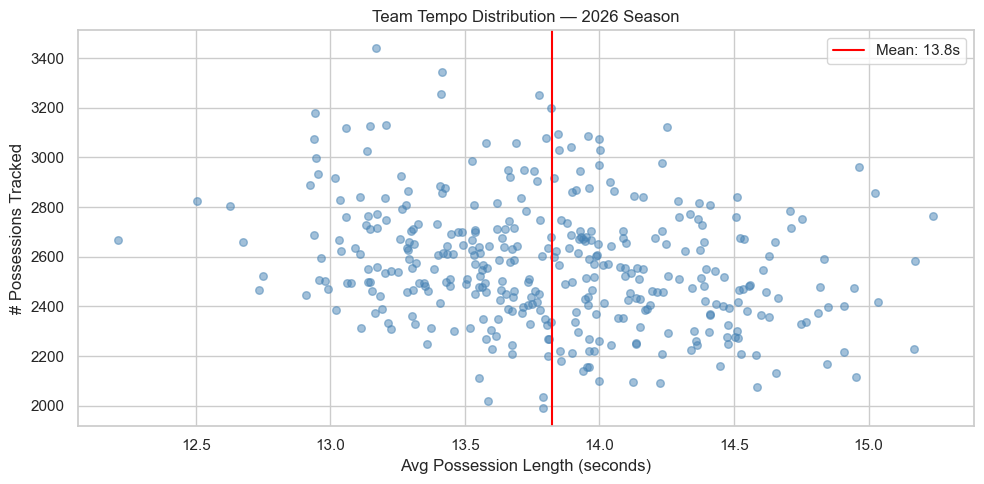

In [19]:
avg_of_avg = tempo_df['avg_possession_sec'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(tempo_df['avg_possession_sec'], tempo_df['possessions_tracked'],
           alpha=0.5, s=30, color='steelblue')
ax.axvline(avg_of_avg, color='red', linewidth=1.5, label=f'Mean: {avg_of_avg:.1f}s')
ax.set_xlabel('Avg Possession Length (seconds)')
ax.set_ylabel('# Possessions Tracked')
ax.set_title('Team Tempo Distribution — 2026 Season')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Shot profile ratio: Calculate the percentage of total shots that are LayUpShot vs. JumpShot───────────────────────

# Find all unique shot types in data
shot_events = df[df['shooting_play'] == True]
print("Unique shot types in your dataset:")
print(shot_events['type_text'].unique())

Unique shot types in your dataset:
['JumpShot' 'LayUpShot' 'MadeFreeThrow' 'TipShot' 'DunkShot' 'Shot']


In [21]:
# ── Shot Profile: Rim Attack / Three-Pointer / Mid-Range ratios per D1 team ──

# df is already D1-filtered; keep only shot attempts
shot_df = df[df['shooting_play'] == True].copy()

# Categorize by type_text (actual values: JumpShot, LayUpShot, DunkShot, TipShot, Shot)
# Three-pointers detected via points_attempted == 3 since type_text has no "three" keyword
is_rim   = shot_df['type_text'].isin(['LayUpShot', 'DunkShot', 'TipShot'])
is_three = (shot_df['points_attempted'] == 3) & ~is_rim

shot_df['shot_category'] = 'Mid-Range'
shot_df.loc[is_rim,   'shot_category'] = 'Rim Attack'
shot_df.loc[is_three, 'shot_category'] = 'Three-Pointer'

# Map team_id (float → "2083.0" string) to team name
team_name_map = (
    pd.concat([
        df[['home_team_id', 'home_team_name']].rename(columns={'home_team_id': 'id', 'home_team_name': 'name'}),
        df[['away_team_id', 'away_team_name']].rename(columns={'away_team_id': 'id', 'away_team_name': 'name'}),
    ])
    .drop_duplicates()
    .assign(id=lambda x: x['id'].astype(float).astype(str))
    .set_index('id')['name'].to_dict()
)

shot_df['team_name'] = shot_df['team_id'].astype(str).map(team_name_map)
shot_df = shot_df.dropna(subset=['team_name'])

# Pivot counts → ratios
shot_counts = shot_df.groupby(['team_name', 'shot_category']).size().unstack(fill_value=0)
for col in ['Rim Attack', 'Three-Pointer', 'Mid-Range']:
    if col not in shot_counts.columns:
        shot_counts[col] = 0
shot_counts['total_shots'] = shot_counts.sum(axis=1)

shot_profile_df = (
    shot_counts[['Rim Attack', 'Three-Pointer', 'Mid-Range', 'total_shots']]
    .rename(columns={'Rim Attack': 'rim_attack_ratio',
                     'Three-Pointer': 'three_pointer_ratio',
                     'Mid-Range': 'mid_range_ratio'})
    .copy()
)
shot_profile_df[['rim_attack_ratio', 'three_pointer_ratio', 'mid_range_ratio']] = (
    shot_profile_df[['rim_attack_ratio', 'three_pointer_ratio', 'mid_range_ratio']]
    .div(shot_profile_df['total_shots'], axis=0)
)
shot_profile_df = shot_profile_df.reset_index()

print("--- TOP 10 RIM-ATTACKING TEAMS ---")
print(shot_profile_df.sort_values('rim_attack_ratio', ascending=False).head(10).to_string(index=False))

--- TOP 10 RIM-ATTACKING TEAMS ---
           team_name  rim_attack_ratio  three_pointer_ratio  mid_range_ratio  total_shots
Cal State Northridge          0.363143             0.250181         0.386676         2762
         Weber State          0.359519             0.235671         0.404810         2495
       Bowling Green          0.358273             0.249679         0.392048         2339
        UMass Lowell          0.355846             0.231743         0.412410         2369
               Brown          0.352654             0.283315         0.364030         1846
          Bellarmine          0.350893             0.298213         0.350893         2183
         Saint Louis          0.350845             0.337619         0.311536         2722
          Seton Hall          0.350298             0.196819         0.452883         2515
           Marquette          0.349268             0.310717         0.340015         2594
             Niagara          0.344542             0.319710      

### Spatial and Shot Quality Features

In [ ]:
# ----------Shot Chart Density: Use the coordinate_x and coordinate_y columns to cluster shot locations. 
# You can classify teams by where they hunt shots (e.g., Rim & 3 Co., Mid-range heavy).

In [27]:
# ── Shot Chart Density: Cluster shot locations into strategic zones ──

# df is already D1-filtered; keep shots with valid coordinates
# Filter out INT32 sentinel overflow values (|x| or |y| > 50/30 are not on any court)
shot_df = (
    df[df['shooting_play'] == True]
    .copy()
    .loc[lambda d: (d['coordinate_x'].abs() <= 50) & (d['coordinate_y'].abs() <= 30)]
)

# Data uses center-origin coords: baskets at ~±41.75 ft from center, sidelines at ±25 ft
# Normalize to one half-court: abs(x) → 0=center court, ~41.75=near basket
shot_df = shot_df.copy()
shot_df['norm_x'] = shot_df['coordinate_x'].abs()   # 0=center, 41.75=rim
shot_df['norm_y'] = shot_df['coordinate_y']          # -25=sideline, 0=lane center, +25=sideline

# Distance from rim (NCAA rim ≈ 41.75 ft from center)
rim_x, rim_y = 41.75, 0.0
shot_df['dist_from_rim'] = np.sqrt((shot_df['norm_x'] - rim_x)**2 + (shot_df['norm_y'] - rim_y)**2)

# Vectorized zone assignment (NCAA 3pt arc ≈ 20.75 ft from rim)
conds = [
    shot_df['dist_from_rim'] <= 6,
    (shot_df['dist_from_rim'] > 6)  & (shot_df['dist_from_rim'] <= 20.75),
    (shot_df['dist_from_rim'] > 20.75) & (shot_df['norm_y'].abs() >= 22),
    (shot_df['dist_from_rim'] > 20.75) & (shot_df['norm_y'].abs() < 8),
]
choices = ['Zone_1_Restricted_Area', 'Zone_2_Mid_Range', 'Zone_3_Corner_3PT', 'Zone_4_Straight_On_3PT']
shot_df['spatial_zone'] = np.select(conds, choices, default='Zone_5_Wing_3PT')

# Map team_id (float → "2083.0" string) to team name
team_name_map = (
    pd.concat([
        df[['home_team_id', 'home_team_name']].rename(columns={'home_team_id': 'id', 'home_team_name': 'name'}),
        df[['away_team_id', 'away_team_name']].rename(columns={'away_team_id': 'id', 'away_team_name': 'name'}),
    ])
    .drop_duplicates()
    .assign(id=lambda x: x['id'].astype(float).astype(str))
    .set_index('id')['name'].to_dict()
)
shot_df['team_name'] = shot_df['team_id'].astype(str).map(team_name_map)
shot_df = shot_df.dropna(subset=['team_name'])

# Zone density per team
zone_counts    = shot_df.groupby(['team_name', 'spatial_zone']).size().unstack(fill_value=0)
zone_densities = zone_counts.div(zone_counts.sum(axis=1), axis=0)
spatial_features_df = zone_densities.reset_index()
print(f"Teams with shot-location data: {len(spatial_features_df)}")
print(spatial_features_df.head())

Teams with shot-location data: 365
spatial_zone          team_name  Zone_1_Restricted_Area  Zone_2_Mid_Range  \
0             Abilene Christian                0.590633          0.173461   
1                     Air Force                0.563419          0.120404   
2                         Akron                0.517462          0.134059   
3                       Alabama                0.510496          0.088740   
4                   Alabama A&M                0.554048          0.208987   

spatial_zone  Zone_3_Corner_3PT  Zone_4_Straight_On_3PT  Zone_5_Wing_3PT  
0                      0.058977                0.046401         0.130529  
1                      0.079504                0.051930         0.184743  
2                      0.096883                0.067217         0.184379  
3                      0.124046                0.071883         0.204835  
4                      0.050869                0.050869         0.135227  


Seton Hall: 2515 shots with valid coordinates


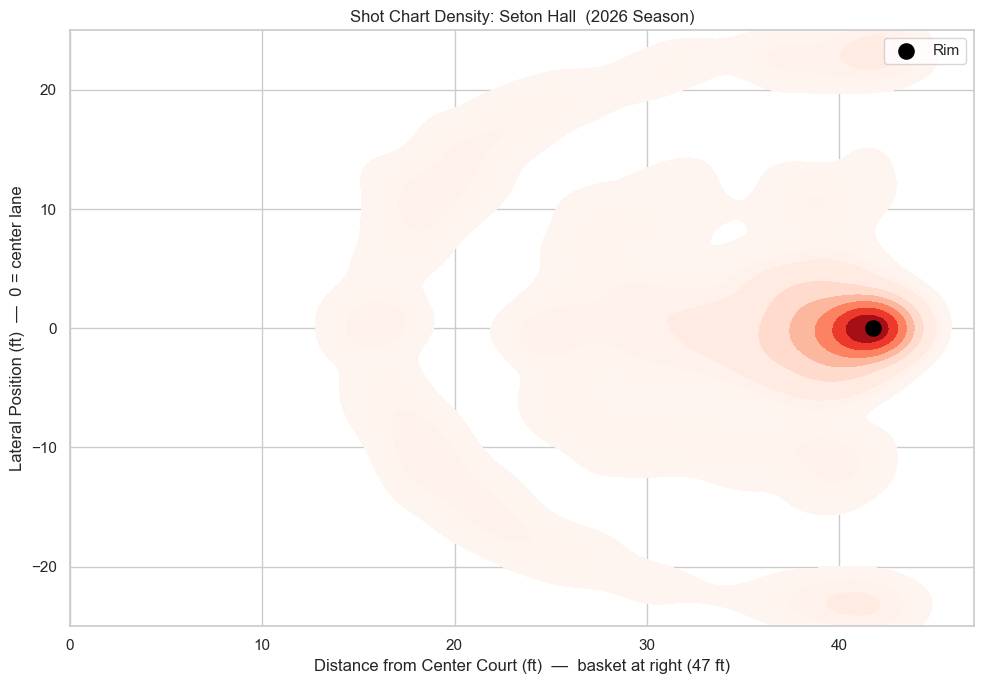

In [28]:
# KDE shot chart for a specific team
target_team = "Seton Hall"
team_shots = shot_df[shot_df['team_name'] == target_team]
print(f"{target_team}: {len(team_shots)} shots with valid coordinates")

fig, ax = plt.subplots(figsize=(10, 7))
sns.kdeplot(
    data=team_shots, x="norm_x", y="norm_y",
    cmap="Reds", fill=True, thresh=0.05, bw_adjust=0.6, ax=ax
)
# Mark rim position
ax.scatter(rim_x, rim_y, color='black', s=120, zorder=5, marker='o', label='Rim')

ax.set_xlim(0, 47)
ax.set_ylim(-25, 25)
ax.set_xlabel("Distance from Center Court (ft)  —  basket at right (47 ft)")
ax.set_ylabel("Lateral Position (ft)  —  0 = center lane")
ax.set_title(f"Shot Chart Density: {target_team}  (2026 Season)")
ax.legend()
plt.tight_layout()
plt.show()